Analyzing map: /Users/evillz/Downloads/error_map.csv
y_sens_um: 1, x_sens_um: 1
Saved SVG to: /Users/evillz/Downloads/error_map.svg


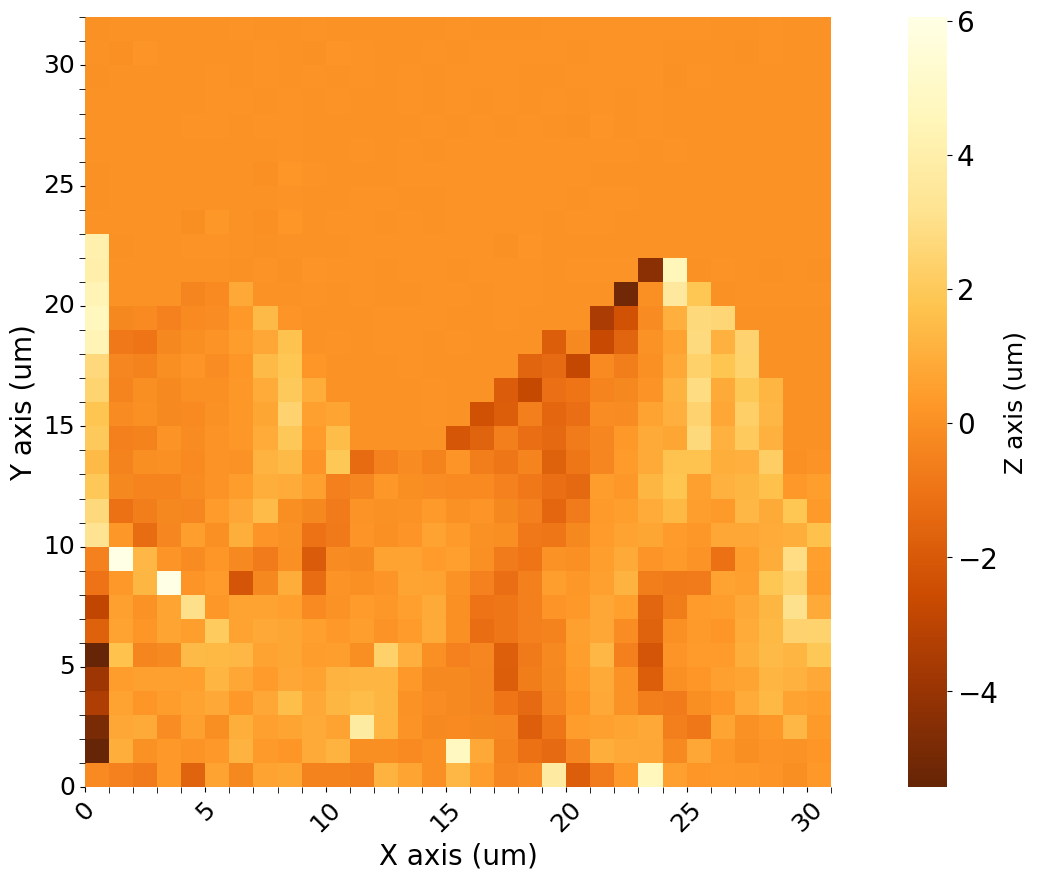

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
map_path = '/Users/evillz/Downloads/error_map.csv'
svg_path = '/Users/evillz/Downloads/error_map.svg'


error_map = pd.read_csv(map_path, delimiter='\t')

def load_2d_map_file_csv_raw(map_path, params=None, flipAxis=True, zmin=None, zmax=None, save_svg=False, svg_path=None, lastColFirst=False, cmap="YlOrBr", delimiter=','):
    """
    Opens a CSV file containing a 2D map of data representing a topographical map.
    Args:
        map_path (str): The path to the CSV file containing the map data.
        params (dict, optional): Dictionary from get_map_parameters to override axis sensitivities and steps.
        flipAxis (bool): If True, flips the Y axis to match the expected orientation.
        zmin (float, optional): Minimum value for the Z axis in the heatmap.
        zmax (float, optional): Maximum value for the Z axis in the heatmap.
        save_svg (bool, optional): Whether to save the heatmap as an SVG file (default is False).
        svg_path (str, optional): Full path where the SVG file should be saved. If None and save_svg is True,
            saves to current directory with name derived from map_path.
        lastColFirst (bool, optional): If True, move the last column to the first position.

    Returns:
        pd.DataFrame: A DataFrame containing the processed map data.
        np.ndarray: The X axis values in micrometers.
        np.ndarray: The Y axis values in micrometers.
    """
    print(f'Analyzing map: {map_path}')
    map_test = pd.read_csv(map_path, header=None, delimiter = delimiter)

    # Default parameters
    defaults = {
        'z_sens_um': 6,
        'x_sens_um': 5.685,
        'y_sens_um': 3.960,
        'map_x_step': 0.14,
        'map_y_step': 0.14,
        'map_x_pix': map_test.shape[1],
        'map_y_pix': map_test.shape[0]
    }

    # Override defaults with params if provided
    if params is not None:
        for k in defaults:
            if k in params:
                defaults[k] = params[k]

    z_sens_um = defaults['z_sens_um']
    x_sens_um = defaults['x_sens_um']
    y_sens_um = defaults['y_sens_um']
    dx_v = defaults['map_x_step']
    dy_v = defaults['map_y_step']
    map_x_pix = defaults['map_x_pix']
    map_y_pix = defaults['map_y_pix']

    # Convert values
    map_test_um = map_test * z_sens_um
    # map_test_um_zeroed = -map_test_um + map_test_um.max().max()
    # map_test_um_zeroed = map_test_um.copy()
    map_test_um_zeroed = map_test_um.copy()


    x_axis = (np.arange(map_x_pix) * dx_v * x_sens_um).round(1)
    y_axis = (np.arange(map_y_pix) * dy_v * y_sens_um).round(1)

    # Define the z-axis range for the colormap
    z_min = zmin if zmin is not None else map_test_um_zeroed.min().min()
    z_max = zmax if zmax is not None else map_test_um_zeroed.max().max()
    vmin = z_min
    vmax = z_max

    # Flip 2D array along vertical axis
    map_test_um_zeroed = np.flip(map_test_um_zeroed.values, axis=1)

    # If lastColFirst is True, move the first column to the last position
    if lastColFirst:
        map_test_um_zeroed = np.roll(map_test_um_zeroed, shift=-1, axis=1)

    fig, ax = plt.subplots(figsize=(20, 10))
    a = sns.heatmap(map_test_um_zeroed, xticklabels=x_axis.round(2), yticklabels=y_axis.round(2), ax=ax, vmin=vmin, vmax=vmax, cmap=cmap)
    a.invert_yaxis()
    xy_axis = -1 if flipAxis else 1
    a.set_aspect((x_sens_um / y_sens_um) ** xy_axis)
    print(f'y_sens_um: {y_sens_um}, x_sens_um: {x_sens_um}')
    a.set_xlabel('X axis (um)', fontsize=20)
    a.set_ylabel('Y axis (um)', fontsize=20)
    colorbar = a.collections[0].colorbar
    colorbar.set_label('Z axis (um)', fontsize=18)
    colorbar.ax.yaxis.label.set_rotation(90)
    _ = plt.xticks(ticks=np.arange(0, len(x_axis), 5), labels=x_axis[::5].round(2), rotation=45, fontsize=18)
    _ = plt.yticks(ticks=np.arange(0, len(y_axis), 5), labels=y_axis[::5].round(2), rotation=0, fontsize=18)
    colorbar.ax.tick_params(labelsize=20)
    filename = os.path.basename(map_path)
    # a.set_title(f'Heatmap: {filename}', fontsize=20)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', length=4, color='black')
    fig.patch.set_alpha(0.0)

    # Save SVG if requested
    if save_svg and svg_path:
        try:
            output_path = svg_path
            if output_path is None:
                base_name = os.path.splitext(os.path.basename(map_path))[0]
                output_path = os.path.join(os.getcwd(), f"{base_name}.svg")
            fig.savefig(output_path, format='svg', bbox_inches='tight', transparent=True)
            print(f"Saved SVG to: {output_path}")
        except Exception as e:
            print(f"Error saving SVG: {e}")

    return map_test_um_zeroed, x_axis, y_axis

params = {
    'z_sens_um': 1,
    'x_sens_um': 1,
    'y_sens_um': 1,
    'map_x_step': 1,
    'map_y_step': 1,

}
map_test_um_zeroed, x_axis, y_axis = load_2d_map_file_csv_raw(map_path, delimiter = '\t', lastColFirst = False,
                                                               save_svg=True, svg_path=svg_path, cmap = "YlOrBr_r",
                                                               params = params 
                                                               
                                                               
                                                               
                                                               
                                                               
                                                               )